# INR Tokenizer Verification

1. **Load:** Import a raw `.pth` file from the dataset.

In [12]:
import torch
import os
import sys

sys.path.append(os.path.abspath('../')) 

from src.tokenizer import INRTokenizer

# Initialize
tokenizer = INRTokenizer()
print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


2. **Tokenize:** Convert the `state_dict` into the nested list structure.

In [13]:
path = "./data/mnist_png_training_0_1/checkpoints/model_final.pth"
state_dict = torch.load(path, map_location='cpu')
tokens = tokenizer.tokenize(state_dict)

print(f"Number of layers tokenized: {len(tokens)}\n")
for i, layer in enumerate(tokens):
    print(f"Layer {i} contains {len(layer)} neuron tokens.\n")
    print(f"Neuron shape from this layer: {layer[0].shape}\n")
    #print(f"Layer list {layer}\n")

Number of layers tokenized: 3

Layer 0 contains 32 neuron tokens.

Neuron shape from this layer: torch.Size([3])

Layer 1 contains 32 neuron tokens.

Neuron shape from this layer: torch.Size([33])

Layer 2 contains 1 neuron tokens.

Neuron shape from this layer: torch.Size([33])



3. **Detokenize:** Reconstruct the `state_dict`.
4. **Check:** Use `torch.equal` to ensure the original and reconstructed tensors are identical.

In [14]:
reconstructed_dict = tokenizer.detokenize(tokens)
for key in state_dict.keys():
    if torch.equal(state_dict[key], reconstructed_dict[key]):
        print(f"✅ {key} is an exact bit-match.")
    else:
        print(f"❌ {key} has changed.")

✅ seq.0.weight is an exact bit-match.
✅ seq.0.bias is an exact bit-match.
✅ seq.1.weight is an exact bit-match.
✅ seq.1.bias is an exact bit-match.
✅ seq.2.weight is an exact bit-match.
✅ seq.2.bias is an exact bit-match.


## Discretizer Test

5. **Discretize:** Quantize the tokens into `n` bins and inspect before/after values.
6. **Rebuild:** Detokenize the quantized tokens back into a `state_dict`.

In [15]:
from src.discretizer import discretize

N_BINS = 100

q_tokens = discretize(tokens, n_bins=N_BINS)

print(f"Discretized with n_bins={N_BINS}\n")
print("--- Before vs After (Layer 0, first 3 neurons, full token) ---")
for i in range(3):
    orig = tokens[0][i]
    quant = q_tokens[0][i]
    print(f"\nNeuron {i}:")
    print(f"  original : {orig.tolist()}")
    print(f"  quantized: {quant.tolist()}")

Discretized with n_bins=100

--- Before vs After (Layer 0, first 3 neurons, full token) ---

Neuron 0:
  original : [0.06459876149892807, 0.030936982482671738, -0.005675104912370443]
  quantized: [0.06565654277801514, 0.03535354137420654, -0.0050505101680755615]

Neuron 1:
  original : [-0.02965756133198738, 0.010647762566804886, 0.01125216856598854]
  quantized: [-0.02525252103805542, 0.015151500701904297, 0.015151500701904297]

Neuron 2:
  original : [0.020368244498968124, 0.07542167603969574, 0.03566013276576996]
  quantized: [0.02525252103805542, 0.07575756311416626, 0.03535354137420654]


In [16]:
q_state_dict = tokenizer.detokenize(q_tokens)

print("--- Quantized state_dict vs original ---")
for key in state_dict.keys():
    orig_w = state_dict[key]
    quant_w = q_state_dict[key]
    max_diff = (orig_w - quant_w).abs().max().item()
    mean_diff = (orig_w - quant_w).abs().mean().item()
    exact = torch.equal(orig_w, quant_w)
    status = "exact match" if exact else f"max_diff={max_diff:.6f}, mean_diff={mean_diff:.6f}"
    print(f"  {key}: {status}")

--- Quantized state_dict vs original ---
  seq.0.weight: max_diff=0.004884, mean_diff=0.001995
  seq.0.bias: max_diff=0.004726, mean_diff=0.002461
  seq.1.weight: max_diff=0.005028, mean_diff=0.002603
  seq.1.bias: max_diff=0.005004, mean_diff=0.002790
  seq.2.weight: max_diff=0.004880, mean_diff=0.002446
  seq.2.bias: max_diff=0.004535, mean_diff=0.004535


## KMeans Discretizer Test

Load several INRs, fit a shared codebook, then compare neurons before and after.

In [ ]:
#Note my file structure is:
#root/
#├─ notebooks/
#│  ├─ data/
#│  │  ├─ mnist-inrs/
#│  │  │  ├─ cifar10_png_train_airplane_0001/
#│  │  │  │  ├─ model_final.pth
#│  │  │  ├─ cifar10_png_train_airplane_0002/
#│  │  │  │  ├─ model_final.pth"
#│  │  │  ├─ ...(keeps going like this)

In [22]:
import random
import numpy as np
from src.discretizer import kmeans_discretize

# Load a small set of INRs to have enough neurons for k=1000
# Each INR has 65 neurons, so we need at least ceil(1000/65) ≈ 16 INRs
checkpoint_dir = "./data/mnist-inrs/"
# Get the paths
pth_files = sorted([
    os.path.join(checkpoint_dir, f)
    for f in os.listdir(checkpoint_dir)
    if f.startswith("mnist_png_training_1")
])  

#take n random inrs from the directory Increasing this decreases the quality of the kmeans reconstructions.
n=1000

pth_files = random.sample(pth_files, n)

# take n INRs → n*65 neurons total (100 inrs → 6500 neurons)
pth_files = [f + "/checkpoints/model_final.pth" for f in pth_files]
print(pth_files)
#print the unique INR numbers
inr_numbers = list(set([f.split("_")[-3].split("/")[0] for f in pth_files]))
inr_numbers.sort()
print(f"INR numbers: {inr_numbers}")

print(f"Loading {len(pth_files)} INRs...")
all_tokens = [tokenizer.tokenize(torch.load(p, map_location="cpu")) for p in pth_files]

total_neurons = sum(len(layer) for inr in all_tokens for layer in inr)
layer_dims = [layer[0].shape[0] for layer in all_tokens[0]]
print(f"Total neurons across all INRs: {total_neurons}")
print(f"Neuron dims per layer (first INR): {layer_dims}")


['./data/mnist-inrs/mnist_png_training_1_31134/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_43261/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_48226/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_47535/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_30430/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_12226/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_24738/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_17043/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_29849/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_34004/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_26479/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_36085/checkpoints/model_final.pth', './data/mnist-inrs/mnist_png_training_1_25812/checkpoints/model_final.pth', './data/mni

In [23]:
K = 10000
print(f"Fitting KMeans with k={K} on {total_neurons} neurons...")
q_all_tokens = kmeans_discretize(all_tokens, k=K)
print("Done.")

# --- Before vs after for the first INR, layer 0 (dim=3, padded to 33 during fit) ---
print("\n--- Layer 0 neurons (dim=3), first 3 neurons of INR 0 ---")
for i in range(3):
    orig  = all_tokens[0][0][i]
    quant = q_all_tokens[0][0][i]
    print(f"  neuron {i}  orig : {orig.tolist()}")
    print(f"  neuron {i}  quant: {quant.tolist()}")

# --- Before vs after for layer 1 (dim=33) ---
print("\n--- Layer 1 neurons (dim=33), first 2 neurons of INR 0 ---")
for i in range(2):
    orig  = all_tokens[0][1][i]
    quant = q_all_tokens[0][1][i]
    diff  = (orig - quant).abs()
    print(f"  neuron {i}  max_diff={diff.max().item():.5f}  mean_diff={diff.mean().item():.5f}")

Fitting KMeans with k=10000 on 65000 neurons...
dim=3: 32000 neurons, k=10000
dim=33: 33000 neurons, k=10000
Done.

--- Layer 0 neurons (dim=3), first 3 neurons of INR 0 ---
  neuron 0  orig : [0.051642850041389465, 0.08481460064649582, 0.0018847848987206817]
  neuron 0  quant: [0.051642850041389465, 0.08481460064649582, 0.0018847848987206817]
  neuron 1  orig : [-0.030255384743213654, 0.028011716902256012, -0.0119319474324584]
  neuron 1  quant: [-0.02973044477403164, 0.02993832342326641, -0.011109808459877968]
  neuron 2  orig : [0.10554235428571701, 0.07827535271644592, 0.036958783864974976]
  neuron 2  quant: [0.10686660557985306, 0.0775807797908783, 0.03729214891791344]

--- Layer 1 neurons (dim=33), first 2 neurons of INR 0 ---
  neuron 0  max_diff=0.00000  mean_diff=0.00000
  neuron 1  max_diff=0.00000  mean_diff=0.00000


In [24]:
# Rebuild state_dicts and check per-tensor error for INR 0
orig_sd  = torch.load(pth_files[0], map_location="cpu")
quant_sd = tokenizer.detokenize(q_all_tokens[0])

print("--- KMeans quantized state_dict vs original (INR 0) ---")
for key in orig_sd.keys():
    diff = (orig_sd[key] - quant_sd[key]).abs()
    print(f"  {key}: max_diff={diff.max().item():.6f}  mean_diff={diff.mean().item():.6f}")

--- KMeans quantized state_dict vs original (INR 0) ---
  seq.0.weight: max_diff=0.003304  mean_diff=0.000844
  seq.0.bias: max_diff=0.003911  mean_diff=0.000733
  seq.1.weight: max_diff=0.040699  mean_diff=0.004032
  seq.1.bias: max_diff=0.008262  mean_diff=0.002461
  seq.2.weight: max_diff=0.000000  mean_diff=0.000000
  seq.2.bias: max_diff=0.000000  mean_diff=0.000000


## KMeans Reconstruction Plot

Render a few INRs before and after KMeans quantization and compare them side by side.

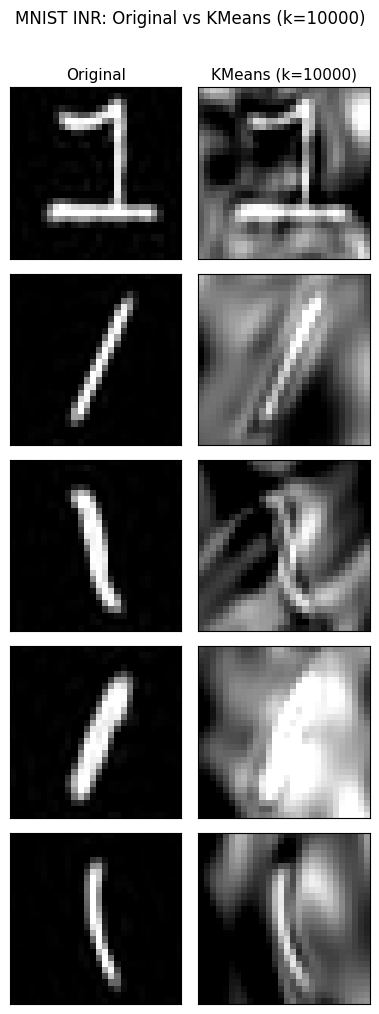

In [25]:
import matplotlib.pyplot as plt
from src.render import render_inr

IMG_SHAPE = (28, 28)
N_SHOW = 5  # number of INRs to display

fig, axes = plt.subplots(N_SHOW, 2, figsize=(4, N_SHOW * 2))
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 1].set_title(f"KMeans (k={K})", fontsize=11)

with torch.no_grad():
    for row, (orig_tok, q_tok) in enumerate(zip(all_tokens[:N_SHOW], q_all_tokens[:N_SHOW])):
        orig_sd = tokenizer.detokenize(orig_tok)
        q_sd = tokenizer.detokenize(q_tok)

        orig_img = render_inr(orig_sd, IMG_SHAPE).clamp(0, 1)
        q_img = render_inr(q_sd, IMG_SHAPE).clamp(0, 1)

        axes[row, 0].imshow(orig_img, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].imshow(q_img, cmap="gray", vmin=0, vmax=1)
        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle(f"MNIST INR: Original vs KMeans (k={K})", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("kmeans_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

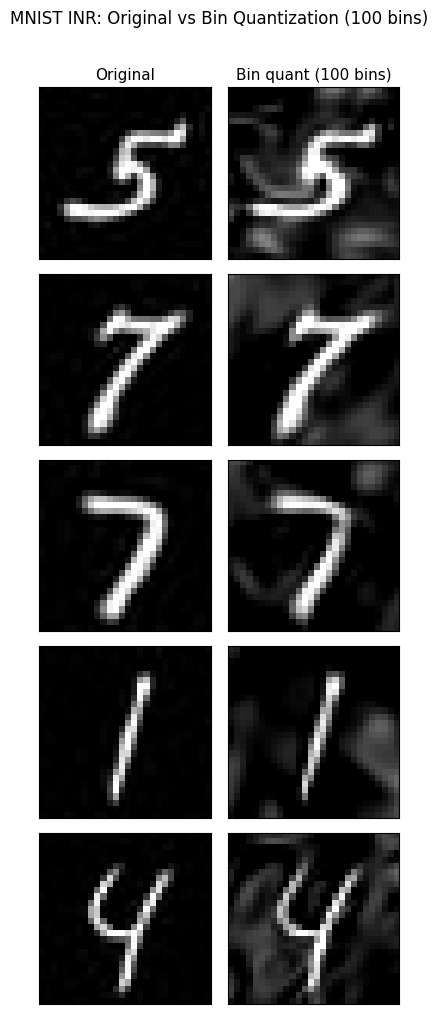

In [47]:
fig, axes = plt.subplots(N_SHOW, 2, figsize=(4, N_SHOW * 2))
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 1].set_title(f"Bin quant ({N_BINS} bins)", fontsize=11)

with torch.no_grad():
    for row, orig_tok in enumerate(all_tokens[:N_SHOW]):
        bin_tok = discretize(orig_tok, n_bins=N_BINS)

        orig_sd = tokenizer.detokenize(orig_tok)
        bin_sd = tokenizer.detokenize(bin_tok)

        orig_img = render_inr(orig_sd, IMG_SHAPE).clamp(0, 1)
        bin_img = render_inr(bin_sd, IMG_SHAPE).clamp(0, 1)

        axes[row, 0].imshow(orig_img, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].imshow(bin_img, cmap="gray", vmin=0, vmax=1)
        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle(f"MNIST INR: Original vs Bin Quantization ({N_BINS} bins)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("bin_quant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()